# Семинар 1. Введение в рекомендательные системы

**Продолжительность**: 1-1.5 часа.
**Аудитория**: базовый Python + pandas.

**Цели**:
- познакомиться с типовым датасетом рекомендаций,
- увидеть sparsity, long-tail, распределение активности,
- получить продуктовое ощущение того, что такое «начальные данные RecSys».

**План**:
1. Импорты, seed, загрузка данных (MovieLens 100K + synthetic fallback).
2. EDA: пользователи, объекты, разреженность.
3. Long-tail, Gini, кривая Лоренца.
4. Segments: активные vs. хвост.
5. Cold-start демонстрация.
6. Практические задачи.


## 1. Импорты и настройки

In [1]:
import os
import io
import zipfile
import urllib.request
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import random
random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)


## 2. Загрузка данных

In [2]:
def try_download_movielens_100k(cache_dir='../../assets/data'):
    '''Пытается скачать MovieLens 100K; при ошибке — None.'''
    os.makedirs(cache_dir, exist_ok=True)
    zip_path = os.path.join(cache_dir, 'ml-100k.zip')
    extract_dir = os.path.join(cache_dir, 'ml-100k')
    ratings_file = os.path.join(extract_dir, 'u.data')
    if os.path.exists(ratings_file):
        return ratings_file
    url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(cache_dir)
        return ratings_file if os.path.exists(ratings_file) else None
    except Exception as e:
        print(f'Не удалось скачать: {e}')
        return None


def generate_synthetic_interactions(n_users=500, n_items=800, n_events=30000, seed=RANDOM_STATE):
    '''Синтетический fallback с длинным хвостом и латентной структурой.'''
    rng = np.random.default_rng(seed)
    # степенное распределение популярности
    item_popularity = rng.pareto(1.2, n_items) + 1
    item_popularity /= item_popularity.sum()
    user_activity = rng.pareto(1.1, n_users) + 1
    user_activity /= user_activity.sum()

    users = rng.choice(n_users, size=n_events, p=user_activity)
    items = rng.choice(n_items, size=n_events, p=item_popularity)
    # Латентные факторы: 5 «жанров»
    latent_dim = 5
    U = rng.normal(0, 1, (n_users, latent_dim))
    V = rng.normal(0, 1, (n_items, latent_dim))
    user_bias = rng.normal(0, 0.3, n_users)
    item_bias = rng.normal(0, 0.3, n_items)
    scores = (U[users] * V[items]).sum(axis=1) * 0.3
    ratings = 3 + user_bias[users] + item_bias[items] + scores + rng.normal(0, 0.4, n_events)
    ratings = np.clip(np.round(ratings), 1, 5).astype(int)
    ts_start = 1_500_000_000
    timestamps = ts_start + rng.integers(0, 3_600 * 24 * 200, size=n_events)
    df = pd.DataFrame({
        'user_id': users.astype(int),
        'item_id': items.astype(int),
        'rating': ratings,
        'timestamp': timestamps,
    })
    df = df.drop_duplicates(subset=['user_id', 'item_id'])
    return df.sort_values('timestamp').reset_index(drop=True)


def load_interactions():
    path = try_download_movielens_100k()
    if path is not None:
        cols = ['user_id', 'item_id', 'rating', 'timestamp']
        df = pd.read_csv(path, sep='\t', names=cols)
        print(f'MovieLens 100K: {len(df)} interactions, users={df.user_id.nunique()}, items={df.item_id.nunique()}')
        return df
    print('Используем синтетический датасет.')
    df = generate_synthetic_interactions()
    print(f'Synthetic: {len(df)} interactions, users={df.user_id.nunique()}, items={df.item_id.nunique()}')
    return df

df = load_interactions()
df.head()


MovieLens 100K: 100000 interactions, users=943, items=1682


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 3. Базовая статистика

In [3]:
n_users = df.user_id.nunique()
n_items = df.item_id.nunique()
n_events = len(df)
sparsity = 1 - n_events / (n_users * n_items)
print(f'users = {n_users:>6}')
print(f'items = {n_items:>6}')
print(f'events = {n_events:>6}')
print(f'sparsity = {sparsity:.4f}')


users =    943
items =   1682
events = 100000
sparsity = 0.9370


## 4. Распределения активности

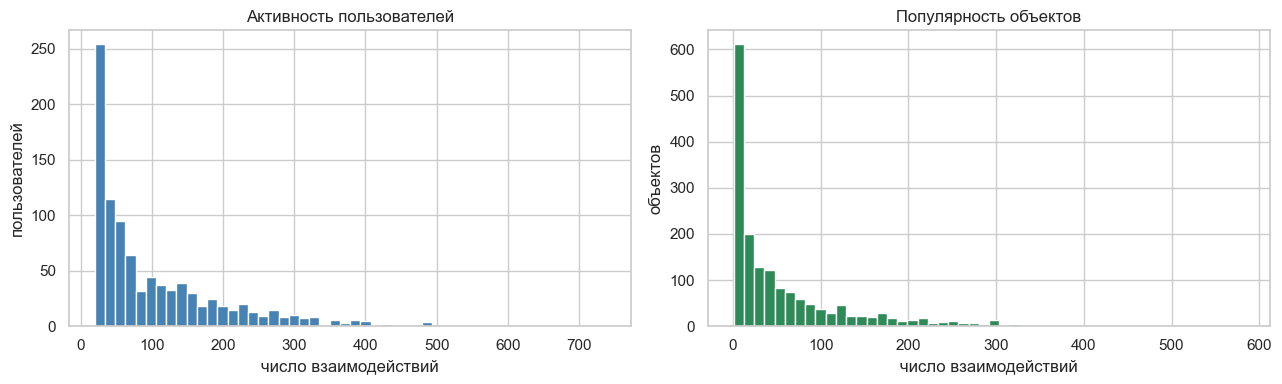

user quantiles: {0.5: 65.0, 0.9: 244.4000000000002, 0.99: 442.54000000000053}
item quantiles: {0.5: 27.0, 0.9: 169.0, 0.99: 369.0900000000006}


In [4]:
user_counts = df.groupby('user_id').size()
item_counts = df.groupby('item_id').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(user_counts, bins=50, color='steelblue')
axes[0].set_title('Активность пользователей')
axes[0].set_xlabel('число взаимодействий'); axes[0].set_ylabel('пользователей')
axes[1].hist(item_counts, bins=50, color='seagreen')
axes[1].set_title('Популярность объектов')
axes[1].set_xlabel('число взаимодействий'); axes[1].set_ylabel('объектов')
plt.tight_layout(); plt.show()

print('user quantiles:', user_counts.quantile([.5, .9, .99]).to_dict())
print('item quantiles:', item_counts.quantile([.5, .9, .99]).to_dict())


## 5. Long-tail и кривая Лоренца

Gini objects: 0.629, Gini users: 0.472


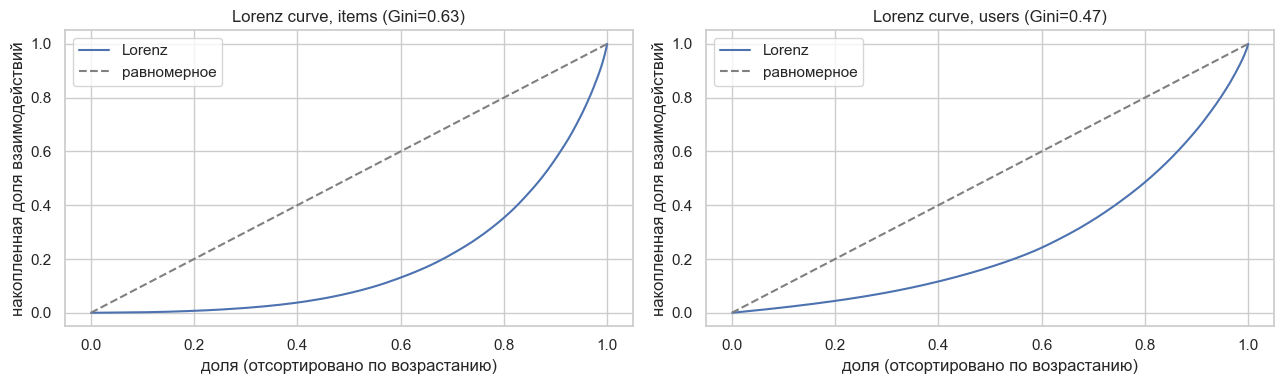

In [5]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0: return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * cum.sum() / cum[-1]) / n

g_item = gini(item_counts.values)
g_user = gini(user_counts.values)
print(f'Gini objects: {g_item:.3f}, Gini users: {g_user:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for arr, name, a in [(item_counts.values, 'items', ax[0]), (user_counts.values, 'users', ax[1])]:
    sorted_arr = np.sort(arr)
    cum = np.cumsum(sorted_arr) / sorted_arr.sum()
    x = np.arange(1, len(cum) + 1) / len(cum)
    a.plot(x, cum, label='Lorenz')
    a.plot([0, 1], [0, 1], '--', color='gray', label='равномерное')
    a.set_title(f'Lorenz curve, {name} (Gini={gini(arr):.2f})')
    a.set_xlabel('доля (отсортировано по возрастанию)')
    a.set_ylabel('накопленная доля взаимодействий')
    a.legend()
plt.tight_layout(); plt.show()


## 6. Top-N и «хвост»

In [6]:
top_percentages = [1, 5, 10, 20]
total = n_events
sorted_pop = item_counts.sort_values(ascending=False).values
rows = []
for p in top_percentages:
    n = max(1, int(len(sorted_pop) * p / 100))
    share = sorted_pop[:n].sum() / total
    rows.append((f'top-{p}%', n, f'{share:.2%}'))
pd.DataFrame(rows, columns=['segment', 'items', 'share of events'])


,segment,items,share of events
0,top-1%,16,7.26%
1,top-5%,84,26.38%
2,top-10%,168,42.70%
3,top-20%,336,64.62%


## 7. Сегментация пользователей

In [7]:
user_segment = pd.qcut(user_counts, q=3, labels=['tail', 'mid', 'head'])
seg_stats = df.assign(segment=df.user_id.map(user_segment)).groupby('segment').agg(
    users=('user_id', 'nunique'),
    events=('user_id', 'size'),
    mean_activity=('user_id', 'size'),
)
seg_stats['mean_activity'] = seg_stats['events'] / seg_stats['users']
seg_stats


,users,events,mean_activity
segment,,,
tail,321,9054,28.205607
mid,308,21742,70.590909
head,314,69204,220.394904


## 8. Cold-start демонстрация

In [8]:
# Разделим по времени: последние 20% -- будущее
tmax = df.timestamp.max()
tmin = df.timestamp.min()
cut = df.timestamp.quantile(0.8)
past = df[df.timestamp <= cut]
future = df[df.timestamp > cut]

new_users = set(future.user_id) - set(past.user_id)
new_items = set(future.item_id) - set(past.item_id)
print(f'В будущем окне: новых пользователей = {len(new_users)}, новых объектов = {len(new_items)}')
print(f'Доля новых событий с новыми пользователями: {future.user_id.isin(new_users).mean():.2%}')
print(f'Доля новых событий с новыми объектами:     {future.item_id.isin(new_items).mean():.2%}')


В будущем окне: новых пользователей = 192, новых объектов = 66
Доля новых событий с новыми пользователями: 85.25%
Доля новых событий с новыми объектами:     1.01%


## Задача 1. Скор популярности top-1%

Посчитайте, какую долю всех взаимодействий собирают top-1% объектов.

**Что сдать**: одна ячейка кода и одно предложение с интерпретацией.

In [ ]:
# YOUR CODE HERE
# 1) Отсортируйте item_counts по убыванию.
# 2) Возьмите первые int(0.01 * n_items) объектов.
# 3) Посчитайте их суммарную долю от n_events.


💡 **Подсказка:** используйте `item_counts.sort_values(ascending=False).iloc[:n]` и `.sum()`.

In [9]:
sorted_item_counts = item_counts.sort_values(ascending=False)
top_1_n = int(0.01 * n_items)
top_1_share = sorted_item_counts.iloc[:top_1_n].sum() / n_events

print(f"Количество top-1% объектов: {top_1_n}")
print(f"Доля взаимодействий: {top_1_share:.2%}")

Количество top-1% объектов: 16
Доля взаимодействий: 7.26%


Всего 1% самых популярных объектов (16 фильмов) собирает более 7% всех взаимодействий в датасете, что указывает на концентрацию пользовательского внимания на небольшом числе хитов и наличие характерного для рекомендательных систем "длинного хвоста".

## Задача 2. k-core фильтрация

Реализуйте функцию `k_core(df, k)`, оставляющую только пользователей и объекты с ≥ k взаимодействиями.

⚠️ Одной итерации недостаточно — после удаления объектов может нарушиться условие для пользователей и наоборот.

In [ ]:
def k_core(df, k=5):
    # YOUR CODE HERE
    # Цикл: фильтруйте пользователей и объекты, пока размер не стабилизируется.
    raise NotImplementedError

# df_k = k_core(df, k=5)

💡 **Подсказка:** `while True: ... if len(new) == len(cur): return new; cur = new`

In [10]:
def k_core(df, k=5):
    cur_df = df.copy()
    while True:
        prev_len = len(cur_df)

        # Фильтруем пользователей
        user_counts = cur_df['user_id'].value_counts()
        valid_users = user_counts[user_counts >= k].index
        cur_df = cur_df[cur_df['user_id'].isin(valid_users)]

        # Фильтруем объекты
        item_counts = cur_df['item_id'].value_counts()
        valid_items = item_counts[item_counts >= k].index
        cur_df = cur_df[cur_df['item_id'].isin(valid_items)]

        # Если размер датафрейма перестал меняться, значит условие выполнено
        if len(cur_df) == prev_len:
            return cur_df

# Проверка работы
df_k = k_core(df, k=5)
print(f"Исходный размер: {len(df)} взаимодействий")
print(f"Размер после 5-core фильтрации: {len(df_k)} взаимодействий")
print(f"Осталось пользователей: {df_k.user_id.nunique()}, объектов: {df_k.item_id.nunique()}")

Исходный размер: 100000 взаимодействий
Размер после 5-core фильтрации: 99287 взаимодействий
Осталось пользователей: 943, объектов: 1349


## Задача 3. Sparsity до и после k-core

Сравните разреженность матрицы user-item до и после k-core(5). Прокомментируйте.

In [ ]:
# YOUR CODE HERE
# посчитайте sparsity до и после и распечатайте


In [11]:
n_users_orig = df.user_id.nunique()
n_items_orig = df.item_id.nunique()
n_events_orig = len(df)
sparsity_orig = 1 - (n_events_orig / (n_users_orig * n_items_orig))

n_users_k = df_k.user_id.nunique()
n_items_k = df_k.item_id.nunique()
n_events_k = len(df_k)
sparsity_k = 1 - (n_events_k / (n_users_k * n_items_k))

print(f"Sparsity до k-core: {sparsity_orig:.4f}")
print(f"Sparsity после 5-core: {sparsity_k:.4f}")

Sparsity до k-core: 0.9370
Sparsity после 5-core: 0.9220


После применения k-core фильтрации разреженность (sparsity) матрицы снижается (то есть матрица становится более плотной). Это происходит потому, что мы отбрасываем "длинный хвост" малоактивных пользователей и непопулярных объектов, которые вносили пустые ячейки в матрицу взаимодействий, при этом сохраняя основную массу самих взаимодействий (событий). На более плотных данных алгоритмам коллаборативной фильтрации (например, матричной факторизации) легче находить закономерности.

## Задача 4. Визуализация Gini для разных k-core

Постройте кривую: значение Gini item_counts как функция от k в k-core (k=1..10).

In [ ]:
# YOUR CODE HERE
# 1) для k in range(1, 11): считайте Gini после k_core
# 2) постройте график k → Gini


💡 **Подсказка:** Не забудьте проверить, что после k-core остались данные.

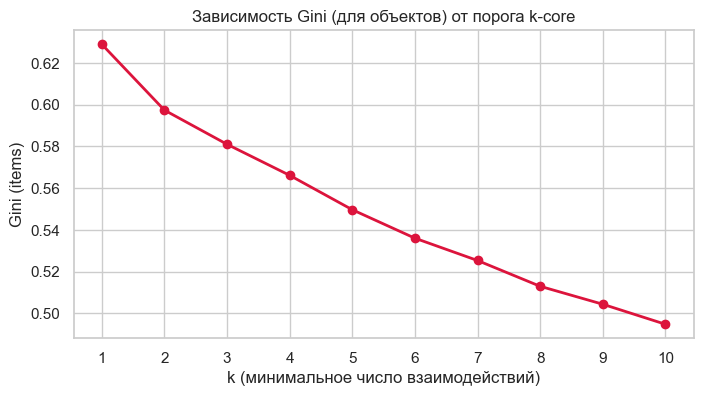

In [12]:
gini_values = []
k_range = range(1, 11)

for k in k_range:
    df_filtered = k_core(df, k)

    # Проверяем, что датафрейм не пустой
    if len(df_filtered) > 0:
        item_counts_k = df_filtered['item_id'].value_counts().values
        g = gini(item_counts_k)
        gini_values.append(g)
    else:
        gini_values.append(np.nan)

# Построение графика
plt.figure(figsize=(8, 4))
plt.plot(k_range, gini_values, marker='o', color='crimson', linewidth=2)
plt.title('Зависимость Gini (для объектов) от порога k-core')
plt.xlabel('k (минимальное число взаимодействий)')
plt.ylabel('Gini (items)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

По мере увеличения k мы отсекаем длинный хвост непопулярных объектов и малоактивных пользователей. Как правило, при удалении большого числа объектов с единичными просмотрами коэффициент Джини немного снижается, так как распределение популярности среди оставшихся "выживших" объектов становится чуть менее скошенным (отсутствует масса объектов около нуля).

## 9. Мини-итоги семинара

- Данные RecSys — сильно разреженные, с длинным хвостом.
- Одинаково важно смотреть на пользователей и на объекты.
- Cold-start и bias видны уже на этом этапе.
- k-core — простой и полезный препроцессинг.

## Чек-лист навыков

- [V] Считаю sparsity и Gini.
- [V] Строю кривую Лоренца.
- [V] Сегментирую пользователей.
- [V] Понимаю разницу между user cold-start и item cold-start.

## Что дальше

В теме 2 закрепим постановку задачи и построим корректные baseline: random, most popular, recent popular, popular by segment.
